In [1]:
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt 
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'sans-serif'] 

# 取得全世界的指數商品

In [2]:
import requests
import pandas as pd 

url = 'https://finance.yahoo.com/markets/world-indices/'
headers = {
    'user-agent' : 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/142.0.0.0 Safari/537.36'
}
req = requests.get(url , headers=headers)
tables = pd.read_html(req.text)
tables[0]

C:\Users\USER\AppData\Local\Temp\ipykernel_25092\4256959621.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(req.text)


,Symbol,Name,Unnamed: 2,Price,Change,Change %,Volume,Day Range,52 Wk Range
0,^GSPC,S&P 500,NaN,"6,812.63 -36.46 (-0.53%)",-36.46,-0.53%,2.787B,"6,799.94 6,843.65","4,835.04 6,920.34"
1,^DJI,Dow Jones Industrial Average,NaN,"47,289.33 -427.09 (-0.90%)",-427.09,-0.90%,482.193M,"47,271.11 47,676.03","36,611.78 48,431.57"
2,^IXIC,NASDAQ Composite,NaN,"23,275.92 -89.76 (-0.38%)",-89.76,-0.38%,6.943B,"23,110.21 23,363.85","14,784.03 24,019.99"
3,^NYA,NYSE Composite Index,NaN,"21,666.46 -158.21 (-0.72%)",-158.21,-0.72%,0,0.00 0.00,"0.00 21,876.99"
4,^XAX,NYSE American Composite Index,NaN,"7,434.52 -35.45 (-0.47%)",-35.45,-0.47%,0,0.00 0.00,"0.00 7,552.82"
5,^BUK100P,Cboe UK 100,NaN,976.33 +3.63 (+0.37%),3.63,+0.37%,0,971.61 976.62,751.90 991.30
6,^RUT,Russell 2000 Index,NaN,"2,469.13 -31.31 (-1.25%)",-31.31,-1.25%,0,"2,468.01 2,488.58","1,732.99 2,541.67"
7,^VIX,CBOE Volatility Index,NaN,16.71 -0.53 (-3.07%),-0.53,-3.07%,0,16.69 17.29,12.70 60.13
8,^FTSE,FTSE 100,NaN,"9,739.51 +36.98 (+0.38%)",36.98,+0.38%,0,"9,694.10 9,742.04","7,544.80 9,930.10"
9,^GDAXI,DAX P,NaN,"23,778.38 +188.94 (+0.80%)",188.94,+0.80%,0,"23,607.70 23,778.38","18,489.91 24,771.34"


In [8]:
def stock_performance( symbols ):
    # 依照商品代碼 將所有的資料下載下來
    data_s = []
    for symbol in symbols:
        data = yf.download(symbol, start='2015-01-01', progress=False)
        data_s.append(data)
    data_total = pd.concat(data_s, axis=1)
    # 計算所有商品的報酬
    ret = data_total['Close'].pct_change()
    # 繪製報酬率曲線圖
    ret_ = ret.dropna()
    (ret_+1).cumprod().plot()
    # 計算各個商品的績效指標
    day_of_year = 242
    ret_yearly= ret.mean() * day_of_year
    day_of_year = 242
    std_yearly = ret.std() * ( day_of_year ** 0.5 )
    sharp_yearly = ret_yearly / std_yearly
    bad_std_yearly = ret[ret<0].std() * ( day_of_year ** 0.5 )
    sortino_ratio = ret_yearly / bad_std_yearly
    mdd = ( (ret+1).cumprod() / (ret+1).cumprod().cummax() -1 ).min()
    newhigh = ((ret+1).cumprod() / (ret+1).cumprod().cummax()) == 1 
    newhigh[ret.isna()] = None
    new_high = newhigh.mean()
    # 將績效指標 合併
    kpi_s = []
    kpi_s.append(ret_yearly)
    kpi_s.append(std_yearly)
    kpi_s.append(sharp_yearly)
    kpi_s.append(sortino_ratio)
    kpi_s.append(mdd)
    kpi_s.append(new_high)
    kpi_table = pd.concat(kpi_s,axis=1)
    kpi_table.columns = ['年化報酬','年化風險','夏普比率','所提諾比率','最大回檔','創高率']
    print(kpi_table)
    kpi_table.to_excel('20251202_全世界指數績效表現.xlsx')
    # 繪製績效指標比較圖
    kpi_table.transpose().plot.bar()
    return kpi_table

# symbols = ['2330.TW','0050.TW'] # 倖存者偏差
# symbols = ['SPY','QQQ','VT','0050.TW','IEI']
# stock_performance(symbols)

C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download

                      年化報酬      年化風險      夏普比率     所提諾比率      最大回檔       創高率
Ticker                                                                      
^GSPC             0.104550  0.163557  0.639224  0.724311 -0.339250  0.130859
^DJI              0.087007  0.159408  0.545810  0.611690 -0.370862  0.103492
^IXIC             0.140916  0.197431  0.713747  0.839659 -0.363953  0.129601
^NYA              0.064697  0.153897  0.420390  0.470530 -0.381142  0.082101
^XAX              0.103809  0.192086  0.540433  0.641531 -0.525914  0.061655
^BUK100P          0.040550  0.141255  0.287070  0.334330 -0.371714  0.037748
^RUT              0.077022  0.209227  0.368127  0.453776 -0.430613  0.045297
^VIX              0.704574  1.252129  0.562701  1.098644 -0.856573   0.00346
^FTSE             0.040185  0.140907  0.285189  0.326694 -0.366055  0.041837
^GDAXI            0.083089  0.174926  0.474993  0.570935 -0.387794  0.071092
^FCHI             0.063900  0.170108  0.375645  0.443335 -0.385585   0.06134

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


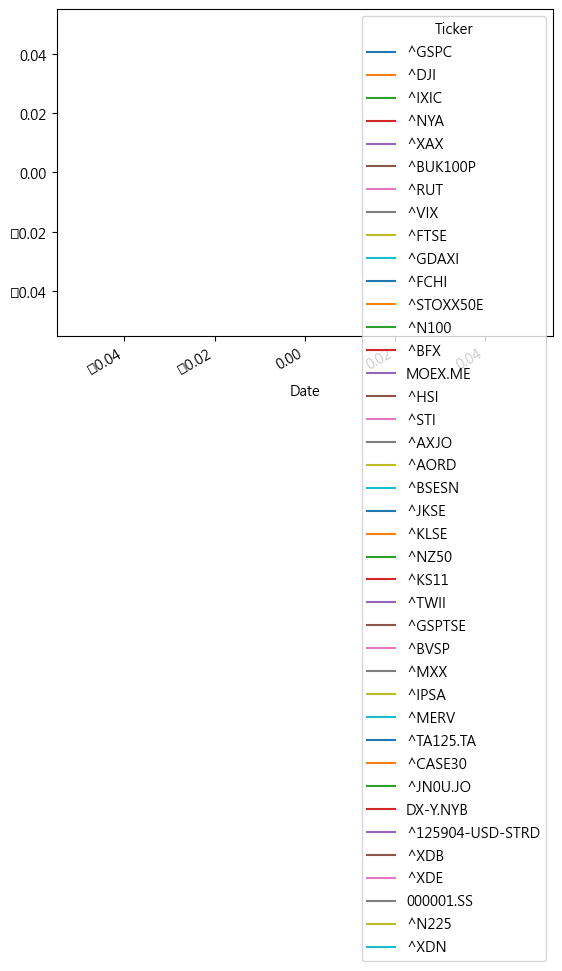

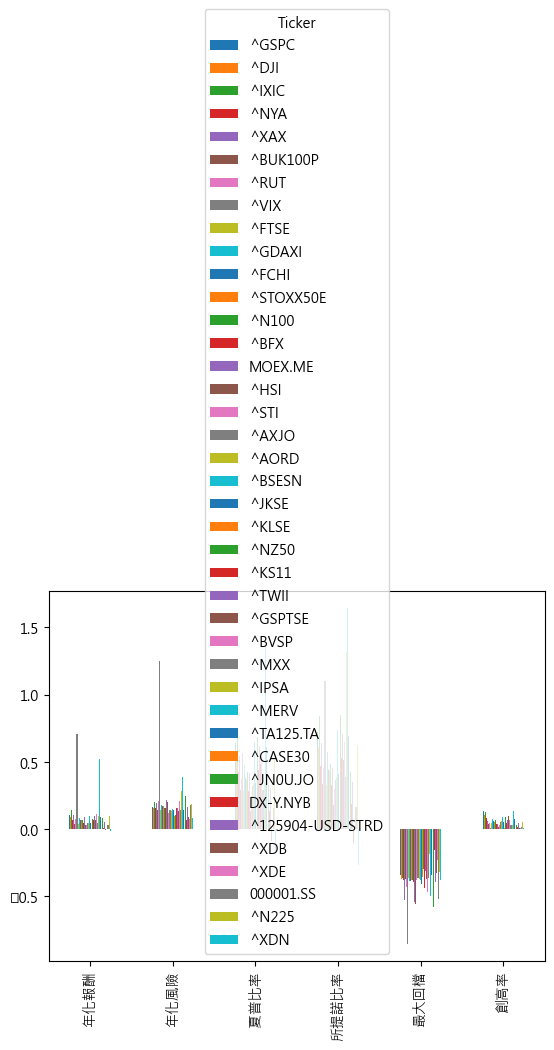

In [10]:
tab = tables[0]
symbols = tab['Symbol'].dropna().tolist()[:40]
kpi_table = stock_performance(symbols)

In [35]:
kpi_table

,年化報酬,年化風險,夏普比率,所提諾比率,最大回檔,創高率
Ticker,,,,,,
^GSPC,0.104550,0.163557,0.639224,0.724311,-0.339250,0.130859
^DJI,0.087007,0.159408,0.545810,0.611690,-0.370862,0.103492
^IXIC,0.140916,0.197431,0.713747,0.839659,-0.363953,0.129601
^NYA,0.064697,0.153897,0.420390,0.470530,-0.381142,0.082101
^XAX,0.103809,0.192086,0.540433,0.641531,-0.525914,0.061655
^BUK100P,0.040550,0.141255,0.287070,0.334330,-0.371714,0.037748
^RUT,0.077022,0.209227,0.368127,0.453776,-0.430613,0.045297
^VIX,0.704574,1.252129,0.562701,1.098644,-0.856573,0.00346
^FTSE,0.040185,0.140907,0.285189,0.326694,-0.366055,0.041837


<Axes: xlabel='年化風險', ylabel='年化報酬'>

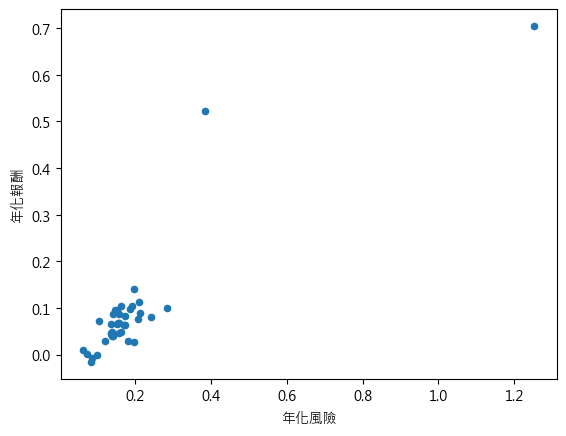

In [12]:
kpi_table.plot.scatter(x='年化風險',y='年化報酬')

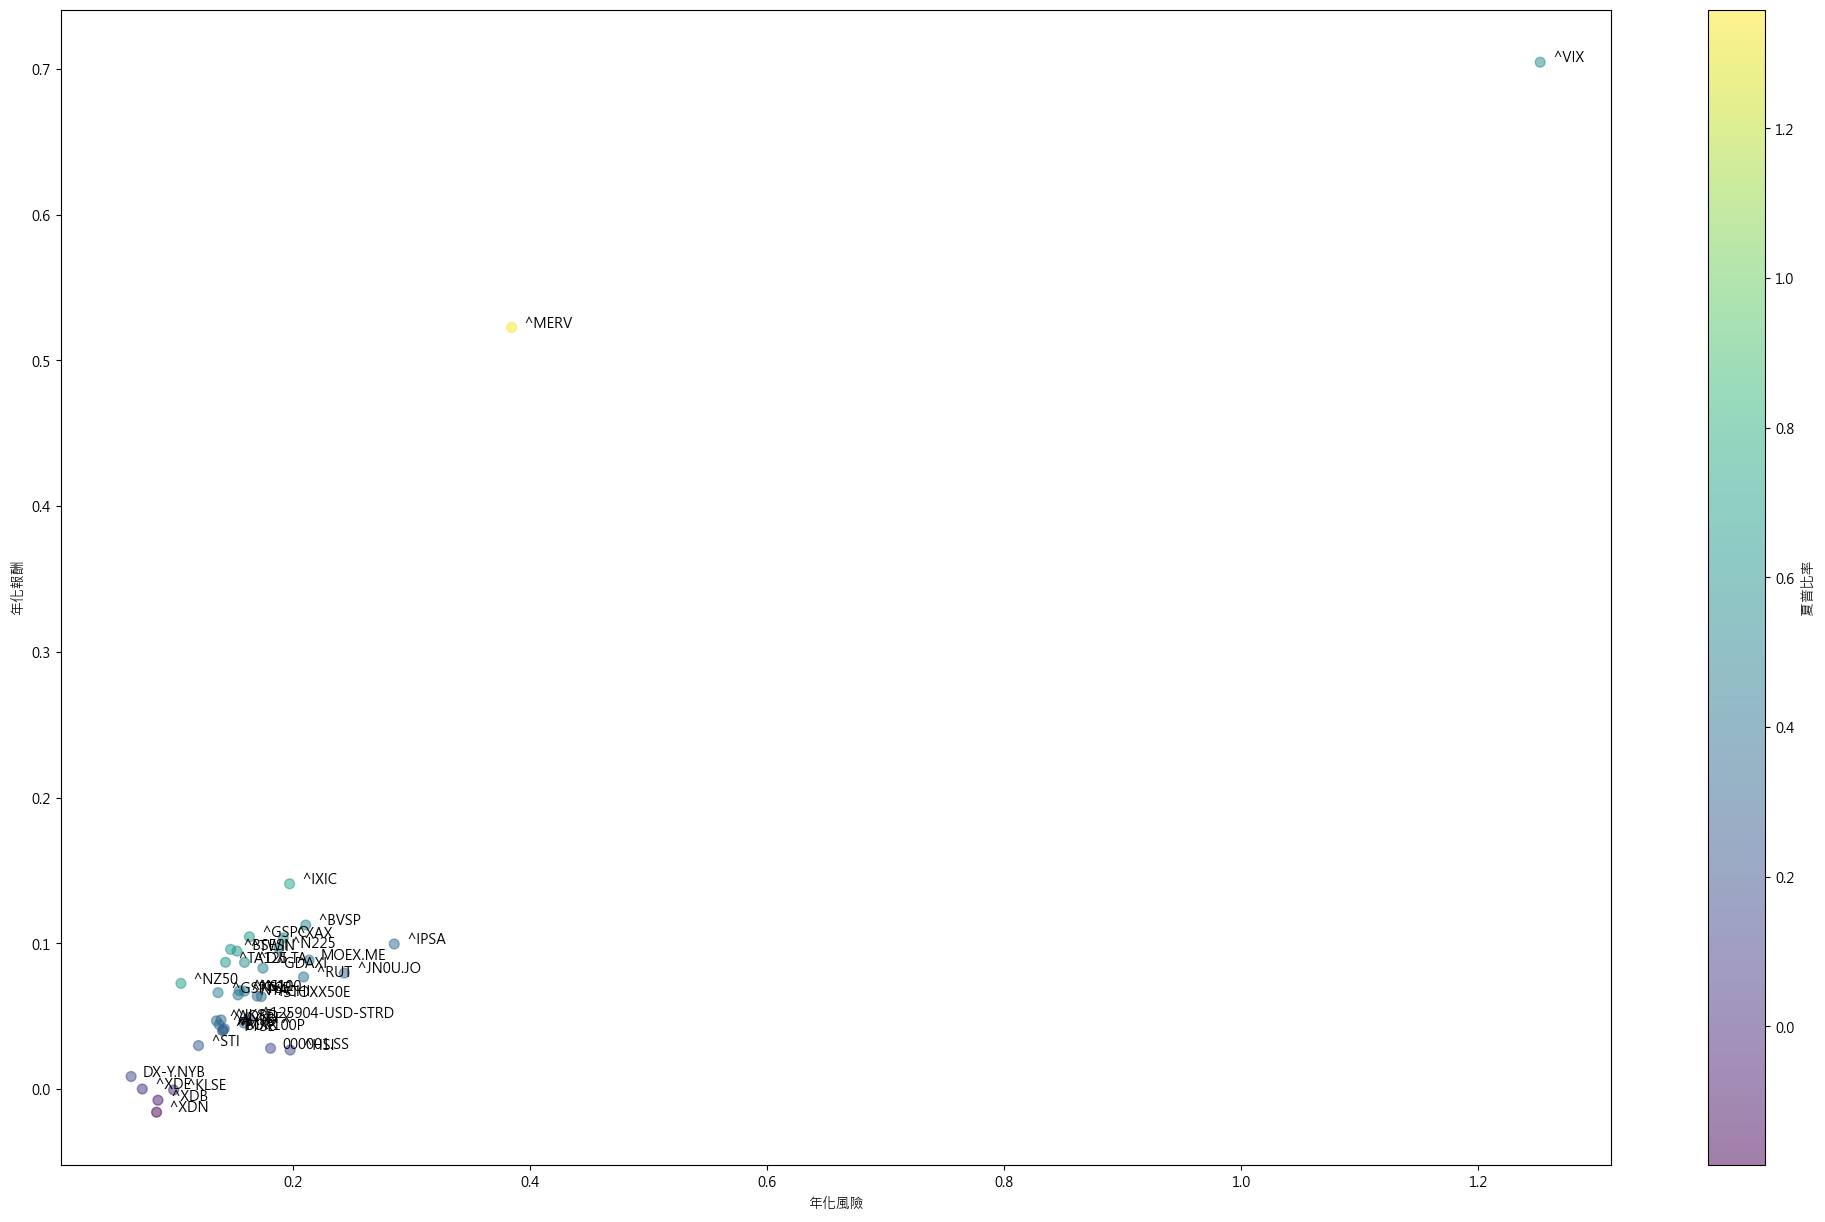

In [29]:
ax = kpi_table.plot.scatter(x="年化風險", y="年化報酬", c="夏普比率", colormap="viridis", figsize=(25, 15), alpha=0.5 , s=50)
for i, txt in enumerate(kpi_table.transpose()):
    ax.annotate(txt, (kpi_table["年化風險"].iloc[i]+0.01 , kpi_table["年化報酬"].iloc[i]))

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


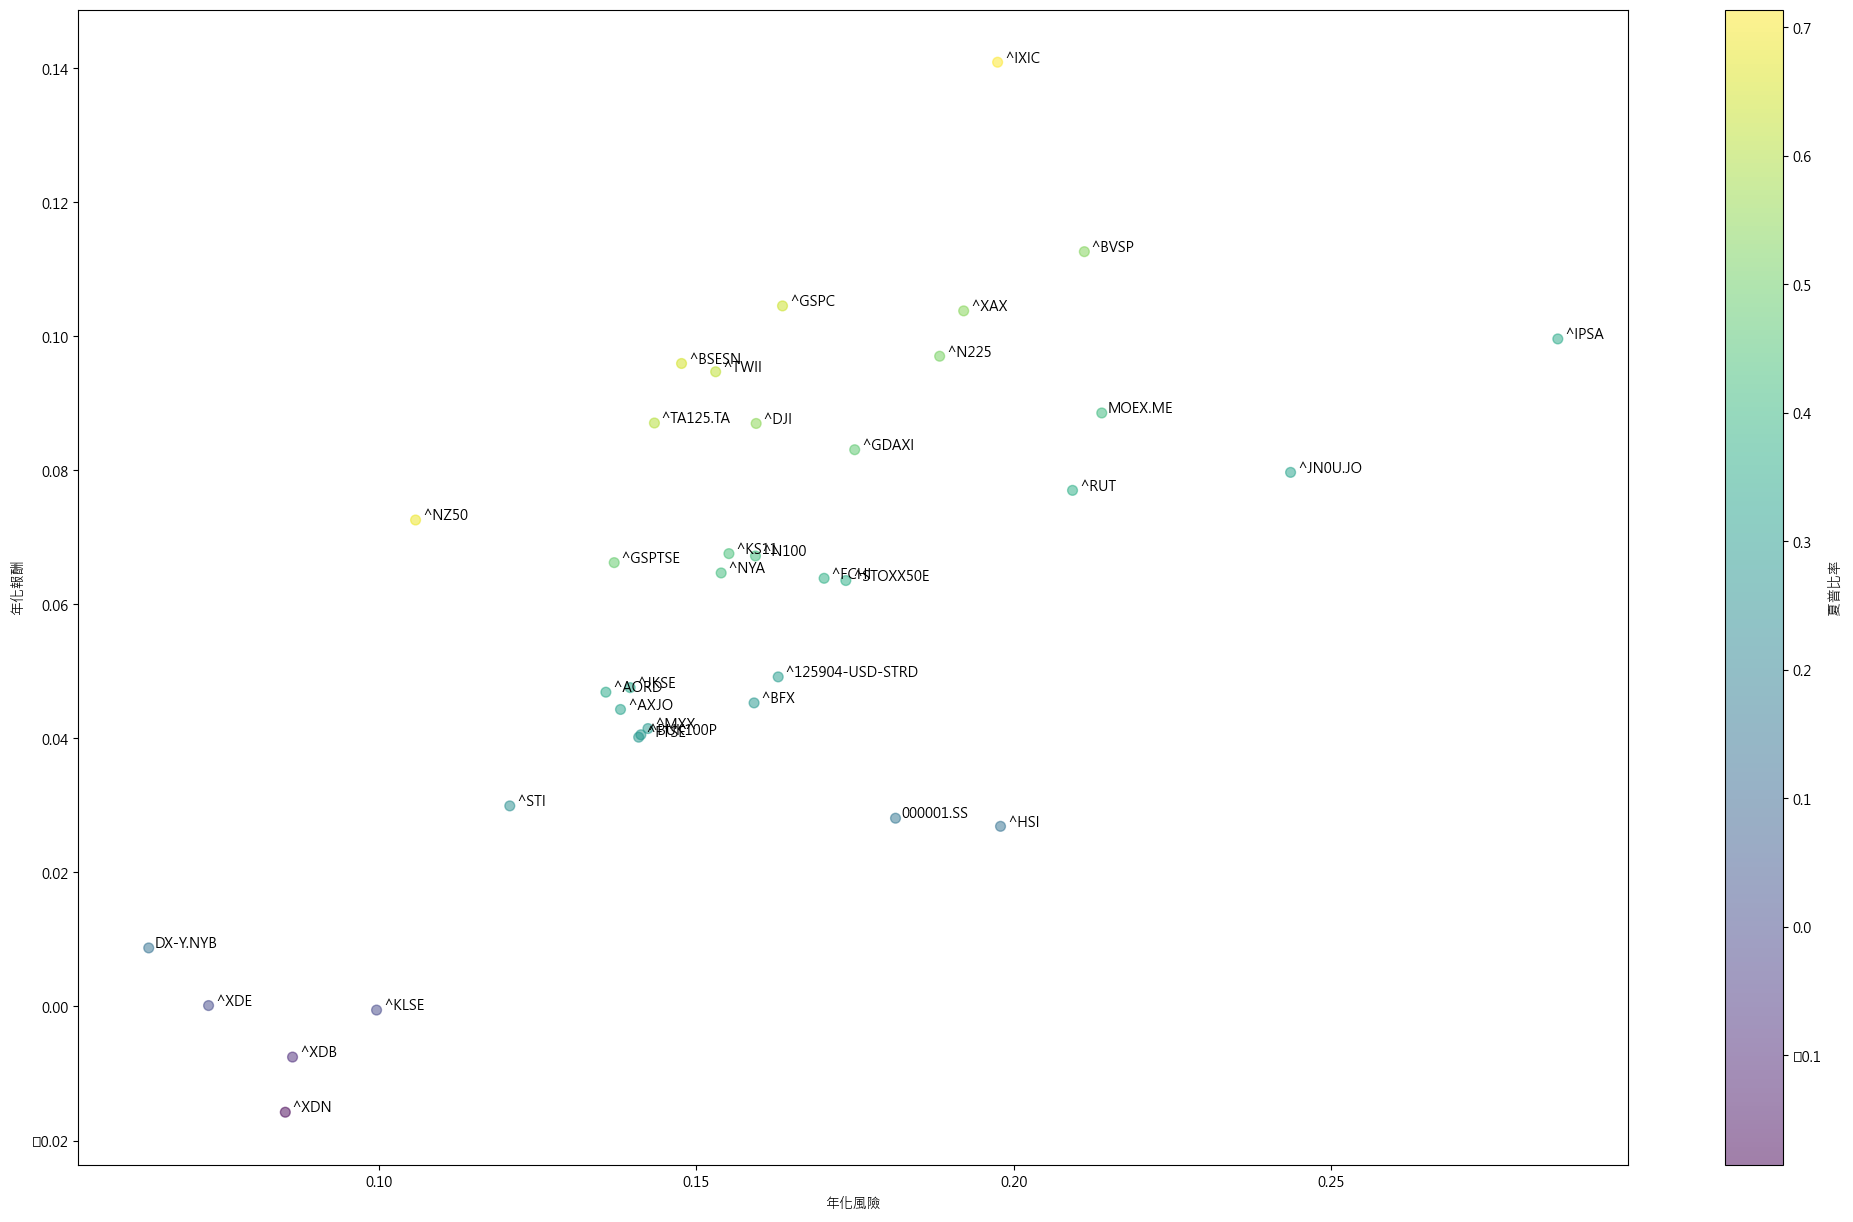

In [34]:
kpi_table_ = kpi_table[kpi_table['年化風險']<=0.35]
ax = kpi_table_.plot.scatter(x="年化風險", y="年化報酬", c="夏普比率", colormap="viridis", figsize=(25, 15), alpha=0.5 , s=50)
for i, txt in enumerate(kpi_table_.transpose()):
    ax.annotate(txt, (kpi_table_["年化風險"].iloc[i]+0.001 , kpi_table_["年化報酬"].iloc[i]))

C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3191749549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kpi_table_['最大回檔'] = kpi_table_['最大回檔'].abs()
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


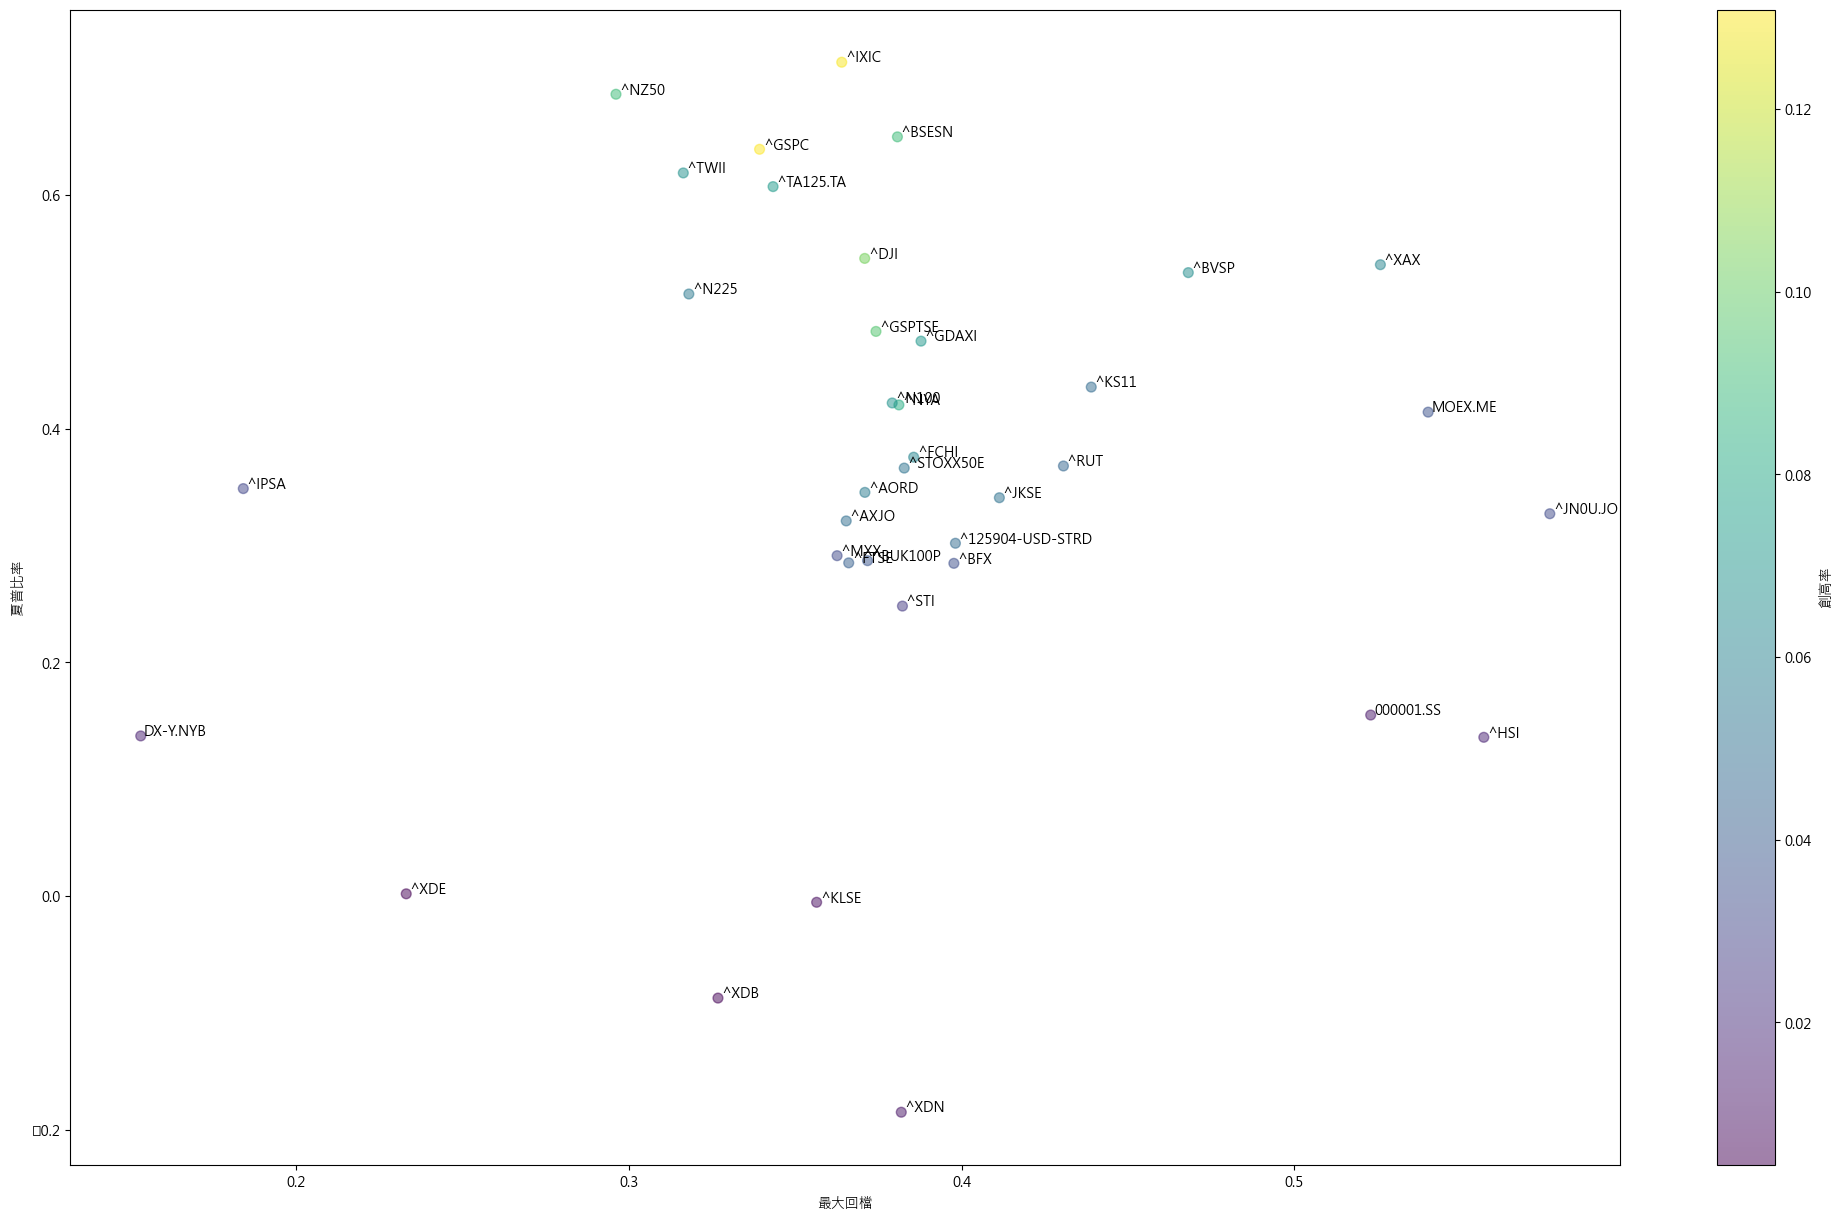

In [41]:
kpi_table_ = kpi_table[kpi_table['年化風險']<=0.35]
kpi_table_['最大回檔'] = kpi_table_['最大回檔'].abs()
ax = kpi_table_.plot.scatter(x="最大回檔", y="夏普比率", c="創高率", colormap="viridis", figsize=(25, 15), alpha=0.5 , s=50)
for i, txt in enumerate(kpi_table_.transpose()):
    ax.annotate(txt, (kpi_table_["最大回檔"].iloc[i]+0.001 , kpi_table_["夏普比率"].iloc[i]))

# 台灣ETF 風險報酬比較

In [42]:
from FinMind.data import DataLoader
api = DataLoader()
df = api.taiwan_stock_info()

2025-12-02 21:11:27.341 | INFO     | FinMind.data.finmind_api:get_data:158 - download Dataset.TaiwanStockInfo, data_id: 


['0054.TW', '00667.TW', '00698L.TW', '00672L.TW', '00699R.TW', '0050.TW', '00762.TW', '00771.TW', '00739.TW', '00850.TW', '00861.TW', '00876.TW', '00738U.TW', '00646.TW', '00647L.TW', '00648R.TW', '00642U.TW', '00660.TW', '00661.TW', '0051.TW', '0053.TW', '0055.TW', '0056.TW', '0061.TW', '006203.TW', '006206.TW', '00631L.TW', '00632R.TW', '00635U.TW', '00637L.TW', '00638R.TW', '00673R.TW', '00707R.TW', '00708L.TW', '00713.TW', '00706L.TW', '00674R.TW', '00680L.TW', '00681R.TW', '00682U.TW', '00683L.TW', '00684R.TW', '00965.TW', '00940.TW']


C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', progress=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_25092\3579166025.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download

               年化報酬      年化風險      夏普比率     所提諾比率      最大回檔       創高率
Ticker                                                               
0054.TW    0.032434  0.143408  0.226166  0.215730 -0.333714  0.024803
00667.TW   0.000000  0.000000       NaN       NaN  0.000000       1.0
00698L.TW  0.000000  0.000000       NaN       NaN  0.000000       1.0
00672L.TW -0.187720  0.588171 -0.319159 -0.286047 -0.982888  0.013435
00699R.TW  0.000000  0.000000       NaN       NaN  0.000000       1.0
0050.TW    0.166780  0.183249  0.910127  1.212101 -0.338276  0.088313
00762.TW   0.244252  0.264730  0.922646  1.214291 -0.385421  0.116307
00771.TW   0.017752  0.143044  0.124100  0.112449 -0.413873  0.036692
00739.TW   0.064268  0.199972  0.321386  0.457054 -0.425296  0.020937
00850.TW   0.212568  0.182106  1.167278  1.456034 -0.280455  0.129327
00861.TW   0.183427  0.198636  0.923429  1.134541 -0.289728  0.104478
00876.TW   0.188885  0.224146  0.842686  1.040184 -0.355240  0.078431
00738U.TW  0.160544 

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  func(*args, **kwargs)


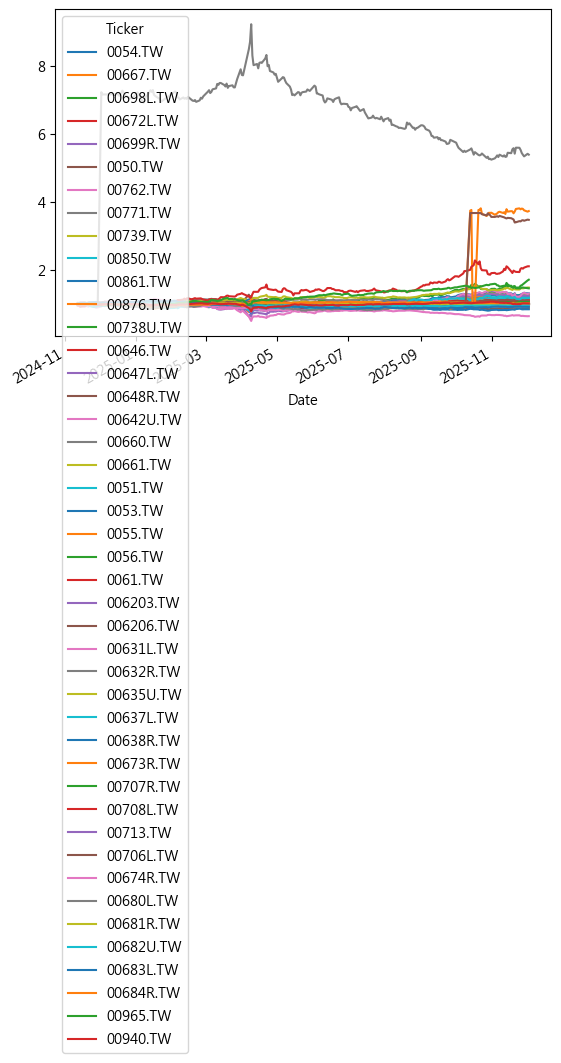

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


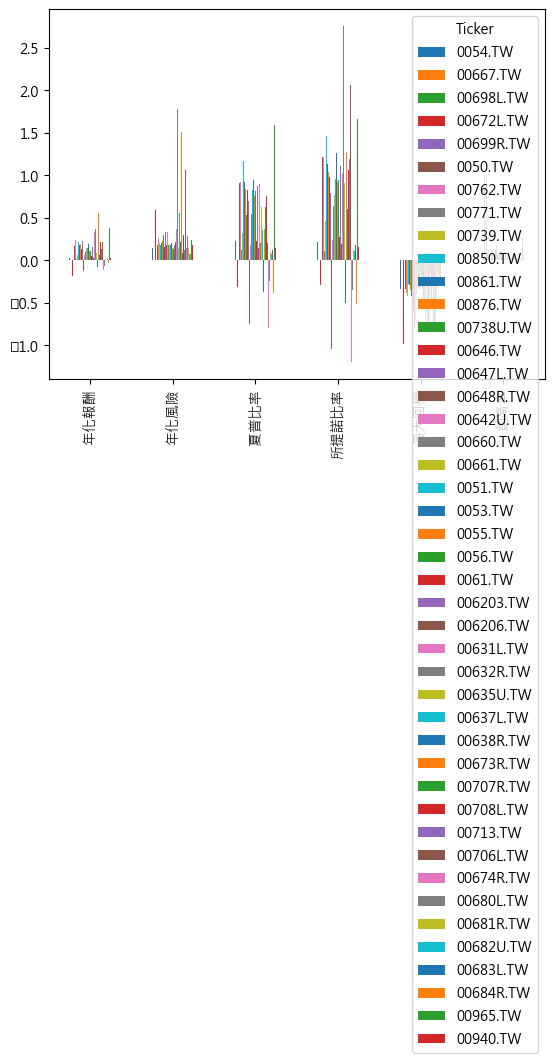

In [48]:
symbols = df[(df['industry_category']=='ETF')&(df['stock_name'].str.contains('元大'))]
symbols = symbols['stock_id'].dropna().tolist()
symbols = [ f"{i}.TW" for i in symbols ]
print(symbols)
kpi_table = stock_performance(symbols)

In [49]:
kpi_table

,年化報酬,年化風險,夏普比率,所提諾比率,最大回檔,創高率
Ticker,,,,,,
0054.TW,0.032434,0.143408,0.226166,0.215730,-0.333714,0.024803
00667.TW,0.000000,0.000000,NaN,NaN,0.000000,1.0
00698L.TW,0.000000,0.000000,NaN,NaN,0.000000,1.0
00672L.TW,-0.187720,0.588171,-0.319159,-0.286047,-0.982888,0.013435
00699R.TW,0.000000,0.000000,NaN,NaN,0.000000,1.0
0050.TW,0.166780,0.183249,0.910127,1.212101,-0.338276,0.088313
00762.TW,0.244252,0.264730,0.922646,1.214291,-0.385421,0.116307
00771.TW,0.017752,0.143044,0.124100,0.112449,-0.413873,0.036692
00739.TW,0.064268,0.199972,0.321386,0.457054,-0.425296,0.020937


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


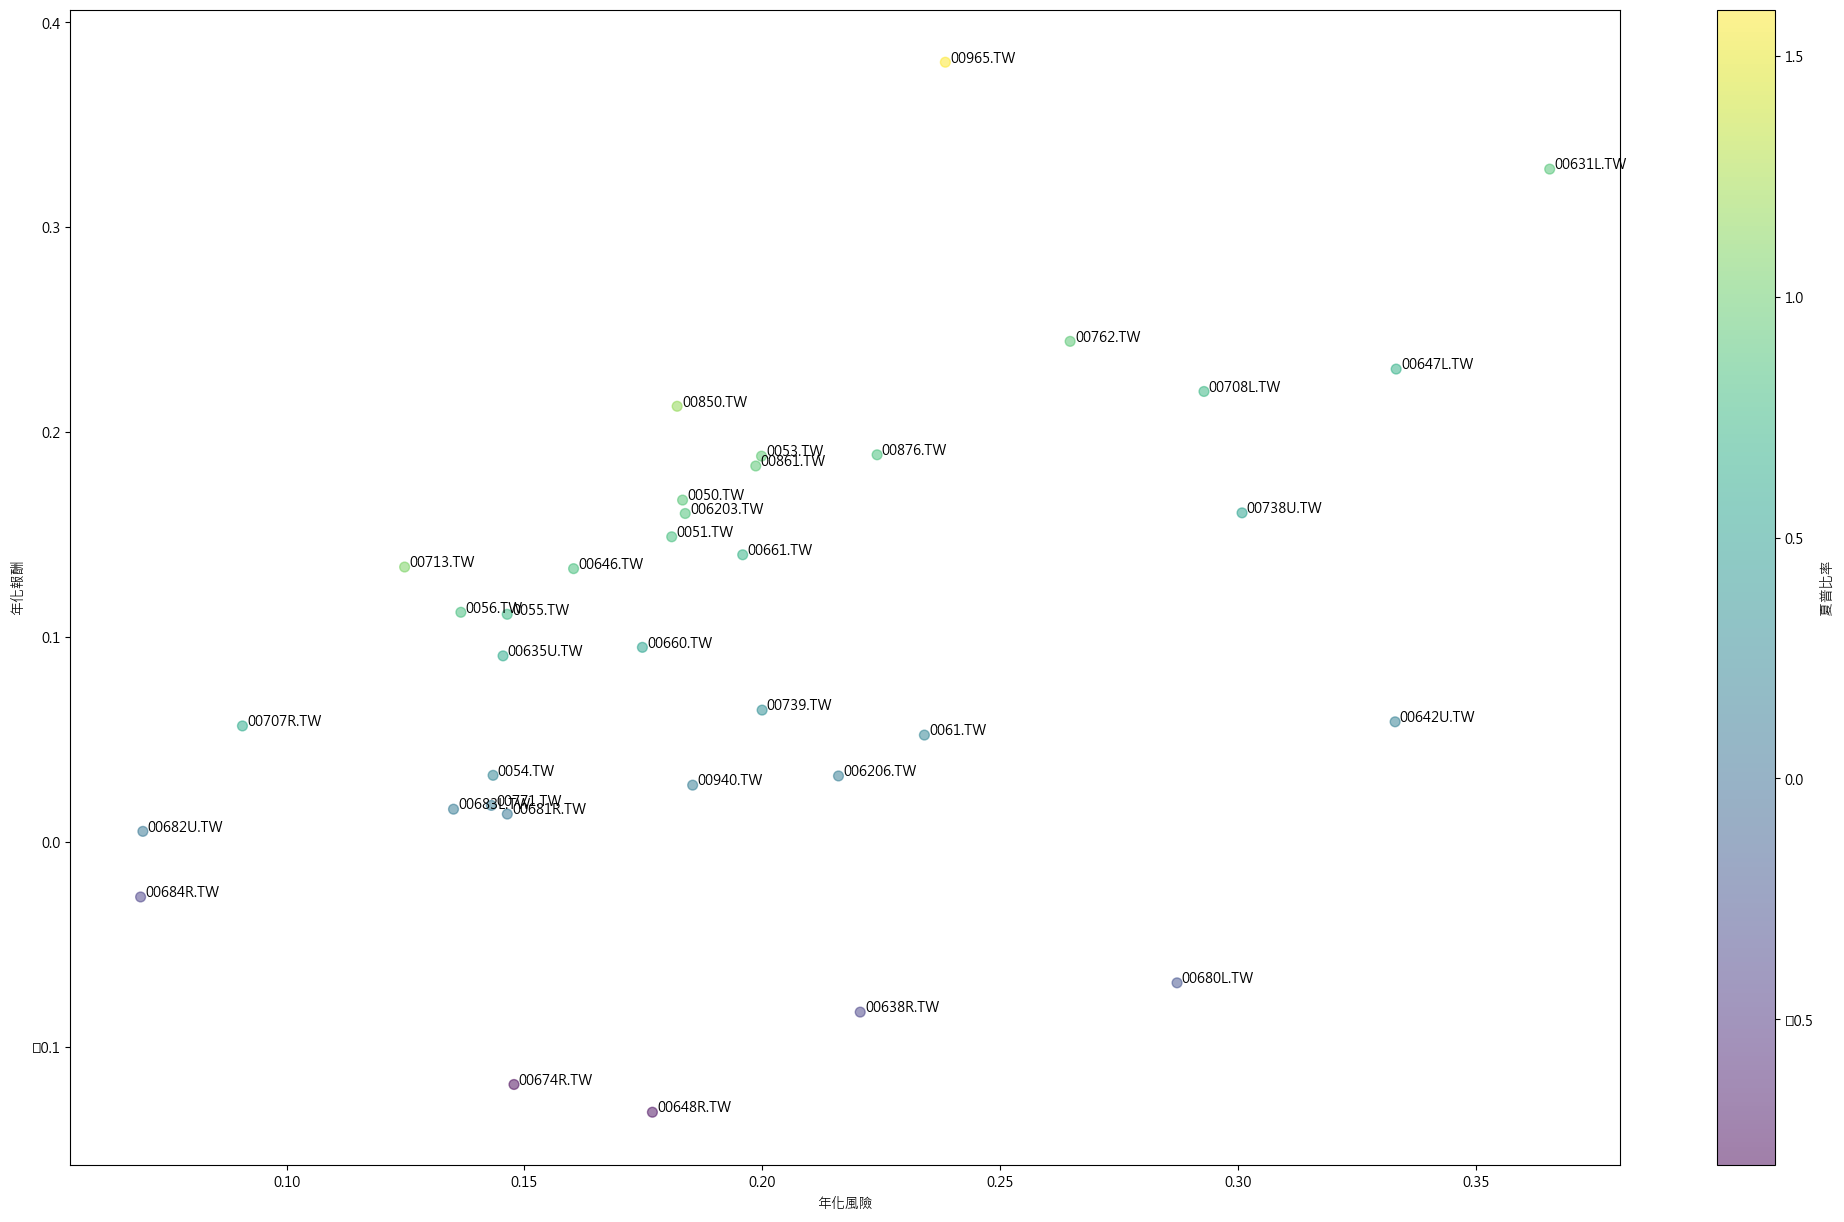

In [ ]:
kpi_table_ = kpi_table[kpi_table['年化風險']<=0.5]
ax = kpi_table_.plot.scatter(x="年化風險", y="年化報酬", c="夏普比率", colormap="viridis", figsize=(25, 15), alpha=0.5 , s=50)
for i, txt in enumerate(kpi_table_.transpose()):
    ax.annotate(txt, (kpi_table_["年化風險"].iloc[i]+0.001 , kpi_table_["年化報酬"].iloc[i]))